# Examples of Lotka–Volterra equation discovery with EPDE framework

This notebook presents an overview of the evolutionary discovery of the Lotka-Volterra equation with the EPDE framework.

In [3]:
import numpy as np
import pandas as pd
import os
import sys
from typing import Union, Callable

import matplotlib.pyplot as plt
import matplotlib as mpl

Add some necessary imports

In [4]:
import sys
sys.path.append('..')
import epde
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['text.usetex'] = False

SMALL_SIZE = 12
mpl.rc('font', size=SMALL_SIZE)
mpl.rc('axes', titlesize=SMALL_SIZE)

# Lotka-Volterra equation introduction.

Lotka–Volterra equations — a compact model describing the predator-prey dynamics of two interacting populations, combining exponential growth/decay with a nonlinear interaction term in a system of two ordinary differential equations:

$$
\begin{cases}
\dfrac{dx}{dt} = \alpha x - \beta xy \\[4pt]
\dfrac{dy}{dt} = \delta xy - \gamma y
\end{cases} \tag{1}
$$

where:

- $x(t)$ — the prey population size at time $t$;
- $y(t)$ — the predator population size at time $t$;
- $t$ — time;
- $\alpha, \beta, \delta, \gamma$ — the four control parameters, governing the growth, predation, and decay rates of the system.

**Where it comes from.** The equations were proposed independently by Alfred J. Lotka (1925) and Vito Volterra (1926) to describe oscillations observed in predator-prey populations, such as fish catches in the Adriatic Sea. Here $\alpha$ is the natural growth rate of prey in the absence of predators, $\beta$ the rate at which predators consume prey, $\delta$ the efficiency of converting consumed prey into predator growth, and $\gamma$ the natural death rate of predators without food. The model is a foundational example in mathematical ecology and population dynamics.

**Example solution.** Unlike the Aizawa and Lorenz systems, this system has no closed-form solution for $x(t), y(t)$ individually — the nonlinear coupling term $xy$ makes it analytically intractable in that sense. However, the system does admit an exact conserved quantity (a first integral of motion), obtained by eliminating $t$ and integrating the resulting separable equation:

$$
H(x, y) = \delta x - \gamma \ln x + \beta y - \alpha \ln y = \text{const}
$$

$$
(x_0, y_0) = (10,\ 5), \tag{2}
$$

using the standard parameter values

You can see illustration of this equation solution below

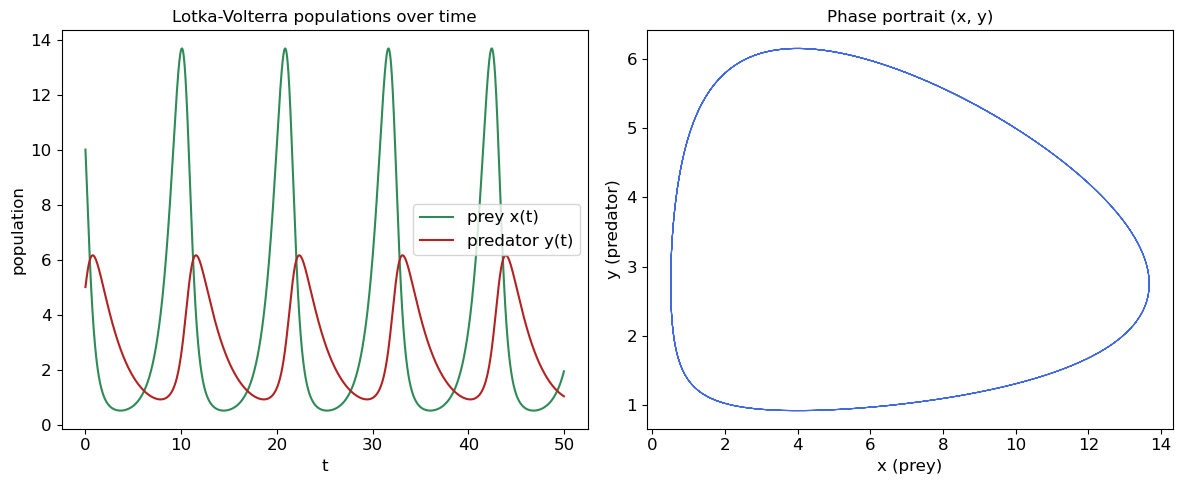

In [5]:
import numpy as np
import matplotlib.pyplot as plt

alpha, beta, delta, gamma = 1.1, 0.4, 0.1, 0.4

def lv_rhs(state, alpha, beta, delta, gamma):
    x, y = state
    dx = alpha * x - beta * x * y
    dy = delta * x * y - gamma * y
    return np.array([dx, dy])

def rk4_step(state, dt, alpha, beta, delta, gamma):
    k1 = lv_rhs(state, alpha, beta, delta, gamma)
    k2 = lv_rhs(state + dt/2 * k1, alpha, beta, delta, gamma)
    k3 = lv_rhs(state + dt/2 * k2, alpha, beta, delta, gamma)
    k4 = lv_rhs(state + dt * k3, alpha, beta, delta, gamma)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

dt = 0.01
n_steps = 5000
state0 = np.array([10.0, 5.0])

trajectory = np.zeros((n_steps, 2))
trajectory[0] = state0

state = state0.copy()
for i in range(1, n_steps):
    state = rk4_step(state, dt, alpha, beta, delta, gamma)
    trajectory[i] = state

x_vals = trajectory[:, 0]
y_vals = trajectory[:, 1]
t_vals = np.arange(n_steps) * dt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t_vals, x_vals, label='prey x(t)', color='seagreen')
axes[0].plot(t_vals, y_vals, label='predator y(t)', color='firebrick')
axes[0].set_xlabel('t')
axes[0].set_ylabel('population')
axes[0].set_title('Lotka-Volterra populations over time')
axes[0].legend()

axes[1].plot(x_vals, y_vals, lw=0.8, color='royalblue')
axes[1].set_xlabel('x (prey)')
axes[1].set_ylabel('y (predator)')
axes[1].set_title('Phase portrait (x, y)')

fig.tight_layout()
plt.show()

To illustrate EPDE algorithm we will use data from file

In [7]:
t_file = "../projects/pic/data/lv/t_20.npy"
t = np.load(t_file)
data_file = "../projects/pic/data/lv/data_20.npy"
data = np.load(data_file)
end = 150
t = t[:end]
x = data[:end, 0]
y = data[:end, 1]


After that we shall initialize equation search object.

In [9]:
from epde.interface.interface import EpdeSearch
epde_search_obj = EpdeSearch(use_solver=False, multiobjective_mode=True, use_pic=True, boundary=15,
                             coordinate_tensors=(t,), verbose_params={'show_iter_idx': True},
                             device='cpu')


setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000255AD65A900>
setting builder with <epde.optimizers.builder.StrategyBuilder object at 0x00000255AD65A900>


Here you can see the explanation of parametrs in EpdeSearch creation:
   -  ``use_solver = False`` — skip the automatic PDE solver when scoring candidate equations; faster, less precise fitness estimate
   - ``multiobjective_mode = True`` — run MOEADD multi-objective search: Pareto front by Discrepancy (quality) + Instability
   - ``use_pic = True`` — define second pareto axis = Instability
   - ``boundary = 15`` — ignore this many grid points from each edge of the domain when computing derivatives
   - ``coordinate_tensors = [t, ]`` — grid coordinate tensors (from np.meshgrid) matching the data array
   - ``device = 'cpu'`` — device for torch computations

In [11]:
epde_search_obj.set_preprocessor(default_preprocessor_type='poly',
                                 preprocessor_kwargs={})

popsize = 12
epde_search_obj.set_moeadd_params(population_size = popsize, training_epochs = 3)


In the cell above we define data preprocessor settings( polynomial derive calculation).
Additional parameters will be population size and number of optimziation epochs: ``training_epochs = 3``.

In [12]:
factors_max_number = {'factors_num': [1, 2], 'probas' : [0.8, 0.2]}

epde_search_obj.fit(data = [x, y], variable_names = ['u', 'v'], max_deriv_order = (2,),
                    equation_terms_max_number=  7, data_fun_pow=3, additional_tokens = [],
                    equation_factors_max_number = factors_max_number)  #


self.vars_demand_equation {'u', 'v'}
best_obj 4

========== Initial population ==========
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[0.87447183 0.84407517 0.36176518 0.02290321]
[3.14305437e-03 8.44075170e-01 1.02979103e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]
[1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02]

========== Marriage (weight assignment) ==========
acute_angles
 [[1.55161369 1.35465424 1.55161478 1.55161369 1.55161369 1.55161369
  1.55161369 1.55161369 1.55161369 1.55161369 1.

Here you can see the explanation of parametrs parametr in fit method:
 - argument ``data`` desctibes array of data grid([x, y])
 - argument ``variable_names`` sets names of target variables
 - argument ``max_deriv_order`` sets the highest order of derivatives, that can be used in equation search
- number of terms, accepted into the structure before regularization is regulated by argument ``equation_terms_max_number``
- argument ``equation_factors_max_number`` defines number of terms in the term can be set as integer (in this case, one number factor will apear in equation with 0.8 probability and two number factor appear with 0.2 probability)
- argument ``additional_tokens`` sets tokens, hat would be used to construct the equations among the main variables and their derivatives
- argument ``data_fun_pow`` describes maximum power of token



The discovered equations can be accessed with ``EpdeSearch.equations()`` method. If the ``only_print = True``, than the equations will be printed in their text forms. 

Otherwise, they will be return: if the followup argument ``only_str`` is ``True``, than the equations are returned only in their symbolic string-form. If ``only_str = False``, than the equation in its program implementation ``epde.structure.main_structures.SoEq`` are returned.

Additional parametr ``num = 2`` define number of poretto-levels for printing

In [ ]:
epde_search_obj.equations(only_print=True, num = 1)



0-th non-dominated level


 / -1.0002115107111698 * dv/dx0{power: 1.0} + 20.02077646386457 * u{power: 1.0} + -20.015180514840953 * v{power: 1.0} + 0.0 = du/dx0{power: 1.0}
 \ -0.7169152241440988 * d^2u/dx0^2{power: 1.0} + 0.0 = d^2v/dx0^2{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 7}, 'max_factors_in_term': {'optimizable': False, 'value': {'factors_num': [1, 2], 'probas': [0.8, 0.2]}}, ('sparsity', 'u'): {'optimizable': True, 'value': np.float64(0.5314758079871306)}, ('sparsity', 'v'): {'optimizable': True, 'value': np.float64(0.002040803051766381)}} , with objective function values of [1.38722097e-03 8.44075170e-01 2.21362949e-06 2.29032087e-02] 

 / -1.00021151071117 * dv/dx0{power: 1.0} + -20.01518051484095 * v{power: 1.0} + 20.020776463864575 * u{power: 1.0} + 0.0 = du/dx0{power: 1.0}
 \ -0.7169152241440988 * d^2u/dx0^2{power: 1.0} + 0.0 = d^2v/dx0^2{power: 1.0}
{'max_terms_number': {'optimizable': False, 'value': 7}, 'max_factors_in_term': {'optimizable': F

We can use visual analysis of the Pareto-optimal set of candidate equations, placed in the complexity-quality criteria space, to select the optimal equation. Method ``EpdeSearch.visualize_solutions()`` illustrates the first non-dominated set of solutions (i.e. Pareto frontier).

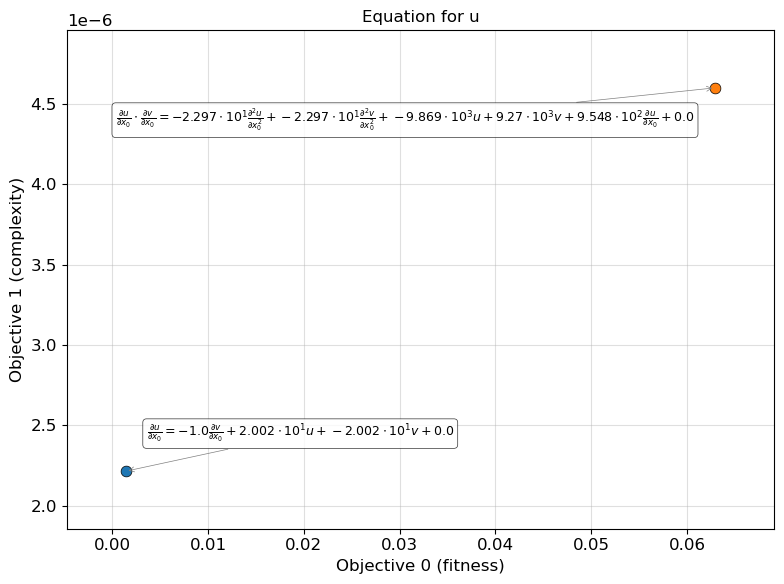

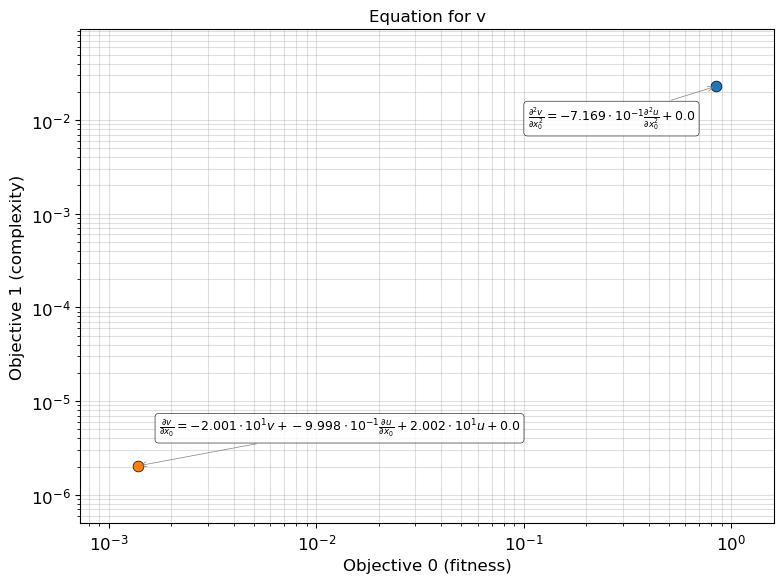

[<Figure size 800x600 with 1 Axes>, <Figure size 800x600 with 1 Axes>]

In [14]:
epde_search_obj.visualize_solutions()